# Moviever project - Exploratory data analysis
**Analyst:** Ethan
**Dataset:** TMDB
**OBjectives:** Identify patterns in the TMDB data to inform Moviever's recommendation

## 1. Setup
Importing the required libraries for data manipulation and visualisation.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## 2. Data Loading
Loading the TMDB dataset from CSV into a pandas DataFrame.

In [2]:
data = pd.read_csv('TMDB_movies.csv')

## 3. Data Inspection & Cleaning
Before any analysis, we inspect the dataset's structure, check for missing values, and review summary statistics. This step ensures we understand what the data contains and where its limitations lie.

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [4]:
data.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


In [5]:
data['release_date'] = pd.to_datetime(data['release_date'], errors='coerce')

### Cleaning Notes
- Null values are present only in `homepage`, `tagline`, and `overview` — none of which are used in this analysis.
- `release_date` is parsed to datetime to enable year-based grouping.

## 4. Genre Analysis and utilising revenue as a measure of Popularity
To explore genre-level performance, the `genres` column is parsed and exploded so each movie contributes one row per genre. This allows accurate aggregation of revenue, profit, movie count, and popularity by genre.

In [6]:
data['profit'] = data['revenue'] - data['budget']
data['genre_names'] = data['genres'].str.findall(r'"name": "([^"]+)"')
data_exploded = data.explode('genre_names')

genre_revenue = data_exploded.groupby('genre_names')['revenue'].mean().sort_values(ascending=False)
genre_count = data_exploded.groupby('genre_names').size().sort_values(ascending=False)
genre_popularity = data_exploded.groupby('genre_names')['popularity'].mean().sort_values(ascending=False)
genre_profit = data_exploded.groupby('genre_names')['profit'].mean().sort_values(ascending=False)

In [7]:
genre_df = pd.DataFrame({
    'genre_revenue': genre_revenue,
    'genre_count': genre_count,
    'genre_popularity': genre_popularity,
    'genre_profit': genre_profit
})
genre_df.index.name = 'genre_names'
genre_df.reset_index(inplace=True)

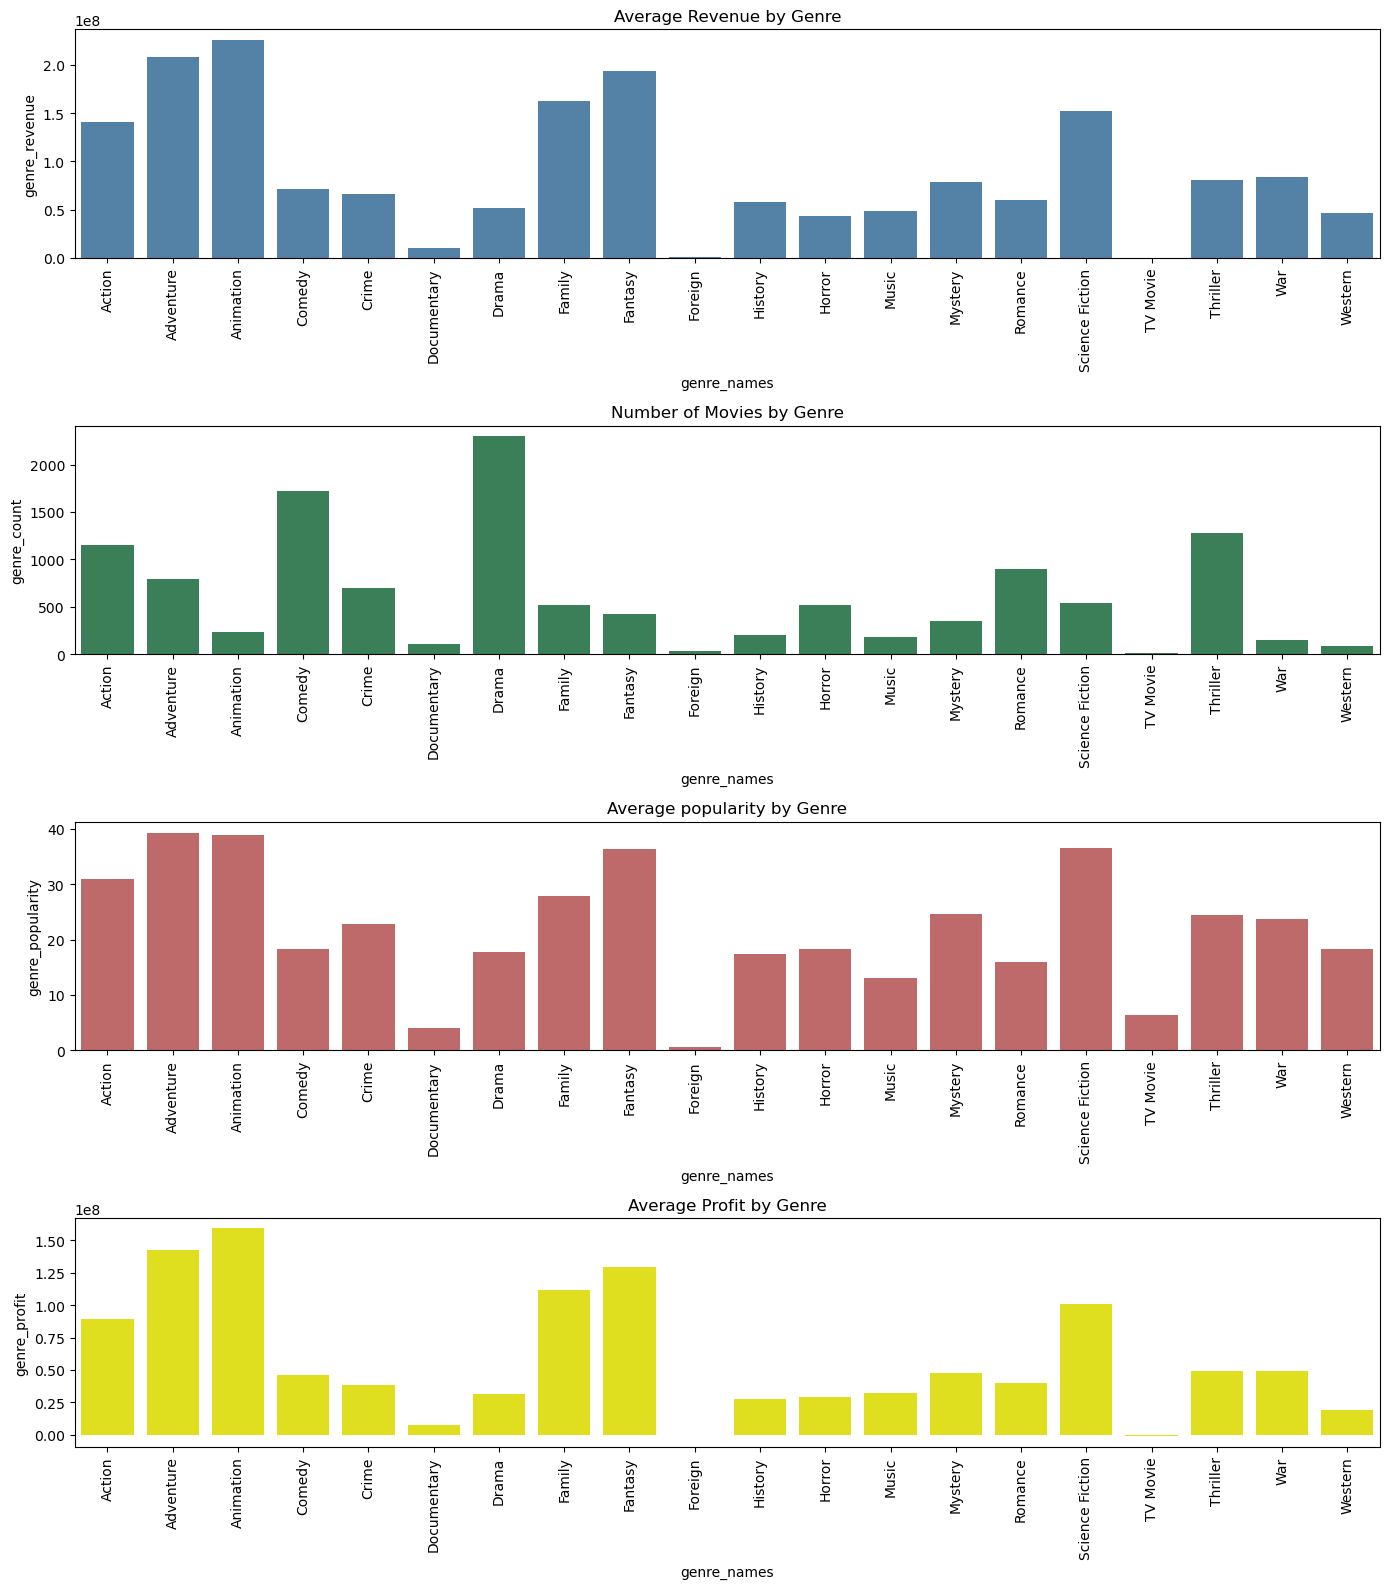

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16))
sns.barplot(data=genre_df, x='genre_names', y='genre_revenue', ax=axes[0], color='steelblue')
axes[0].set_title('Average Revenue by Genre')
sns.barplot(data=genre_df, x='genre_names', y='genre_count', ax=axes[1], color='seagreen')
axes[1].set_title('Number of Movies by Genre')
sns.barplot(data=genre_df, x='genre_names', y='genre_popularity', ax=axes[2], color='indianred')
axes[2].set_title('Average popularity by Genre')
sns.barplot(data=genre_df, x='genre_names', y='genre_profit', ax=axes[3], color='yellow')
axes[3].set_title('Average Profit by Genre')

for ax in axes:
    ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

### Genre Insights

Action, Adventure, Animation, Family, Fantasy and Science Fiction consistently outperform other genres across average revenue, average profit and popularity score by a significant margin.

If prioritising a single genre for recommendations, Action is the strongest choice. It scores highly on both revenue and popularity while containing the largest volume of films in the dataset — meaning there is sufficient variety to serve users repeatedly without exhausting the catalogue.

Notably, average revenue and popularity show a near 1:1 agreement in their rankings across all genres. This suggests popularity is a reliable proxy for commercial performance, and either metric could reasonably be used to inform content weighting in a recommendation pipeline.

## 5. Rating vs. Revenue
Here we explore whether a higher audience rating correlates with higher box office revenue. Movies are grouped into rating bins (rounded to the nearest integer) and average revenue per bin is calculated.

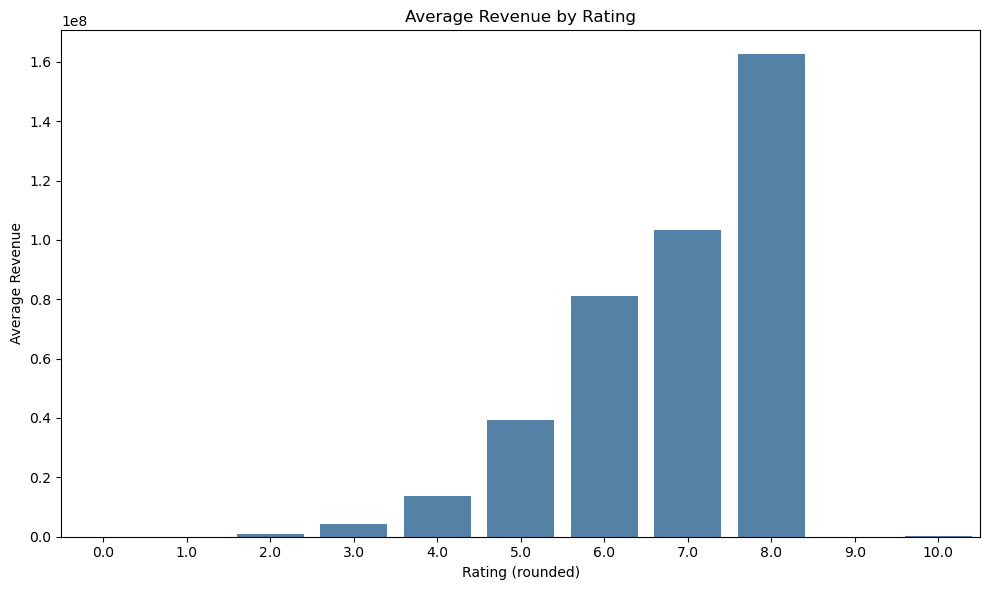

In [9]:
data['rating_bin'] = data['vote_average'].round(0) 
rating_revenue = data.groupby('rating_bin')['revenue'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=rating_revenue, x='rating_bin', y='revenue', color='steelblue')
plt.title('Average Revenue by Rating')
plt.xlabel('Rating (rounded)')
plt.ylabel('Average Revenue')
plt.tight_layout()
plt.show()

### Rating vs. Revenue Insights

The chart demonstrates a strong positive relationship between audience rating and average revenue, as ratings increase from 2 to 8, revenue rises consistently and steeply. This is a significant finding: it means that rating and revenue are broadly in agreement as measures of a film's success, reinforcing the conclusion from the genre analysis that revenue is a reliable signal for audience approval.

The drop-off at ratings 9 and 10 is not a genuine reversal of this trend. Films achieving near-perfect scores are extremely niche and typically have only one or two reviewers and are therefore statistically unrepresentative. Excluding these outliers, the relationship between rating and revenue is effectively linear.

This has a direct implication for recommendations: revenue could serve as a strong proxy signal for quality. A recommendation engine without access to explicit user ratings could weight films by revenue and expect results that broadly align with what high-rating-based filtering would produce.

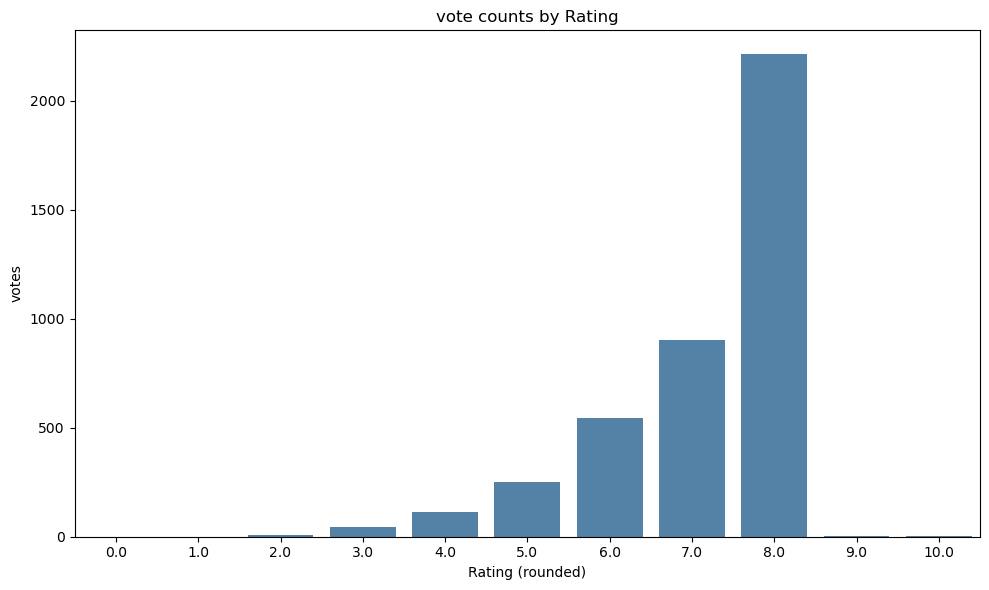

In [10]:
data['rating_bin'] = data['vote_average'].round(0) 
rating_votes = data.groupby('rating_bin')['vote_count'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=rating_votes, x='rating_bin', y='vote_count', color='steelblue')
plt.title('vote counts by Rating')
plt.xlabel('Rating (rounded)')
plt.ylabel('votes')
plt.tight_layout()
plt.show()

## 7. Movie Deep-Dive: Avengers: Age of Ultron vs. Pirates of the Caribbean: At World's End

In [11]:
movie1 = data[data['id'] == 99861].iloc[0]
movie2 = data[data['id'] == 285].iloc[0]
comparison = pd.DataFrame({
    'movie1': movie1[['title', 'budget', 'revenue', 'profit', 'vote_average', 'runtime']],
    'movie2': movie2[['title', 'budget', 'revenue', 'profit', 'vote_average', 'runtime']]
})
comparison

,movie1,movie2
title,Avengers: Age of Ultron,Pirates of the Caribbean: At World's End
budget,280000000,300000000
revenue,1405403694,961000000
profit,1125403694,661000000
vote_average,7.3,6.9
runtime,141.0,169.0


### Deep-Dive Insights

Avengers: Age of Ultron and Pirates of the Caribbean: At World's End  were selected for their near-identical production costs, making them a fair like-for-like comparison. Despite comparable investment, Age of Ultron generated $1.4B$ in revenue against At World's End's $961M$ — a profit difference of over $460M in favour of the MCU film. Audience ratings are broadly similar (7.3 vs 6.9), ruling out quality as the explanatory factor. This raises the question: what accounts for the gap?

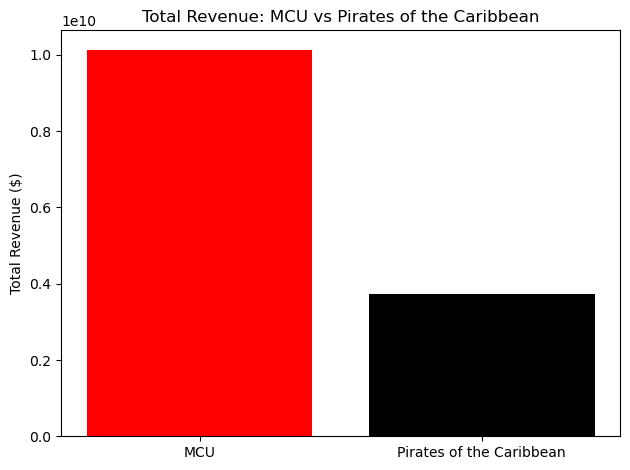

In [12]:
data['keyword_names'] = data['keywords'].str.findall(r'"name": "([^"]+)"')
data_exploded_2 = data.explode('keyword_names')
pirates_movies = data[data['title'].str.contains('Pirates of the Caribbean', case=False, na=False)]
mcu_movies = data_exploded_2[data_exploded_2['keyword_names'] == 'marvel cinematic universe']
franchises = ['MCU', 'Pirates of the Caribbean']
avg_revenues = [mcu_movies['revenue'].sum(), pirates_movies['revenue'].sum()]
plt.bar(franchises, avg_revenues, color=['red', 'black'])
plt.title('Total Revenue: MCU vs Pirates of the Caribbean')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

The MCU generated approximately $10B$ in total franchise revenue versus $3.7B$ for Pirates of the Caribbean — nearly three times as much across its catalogue.

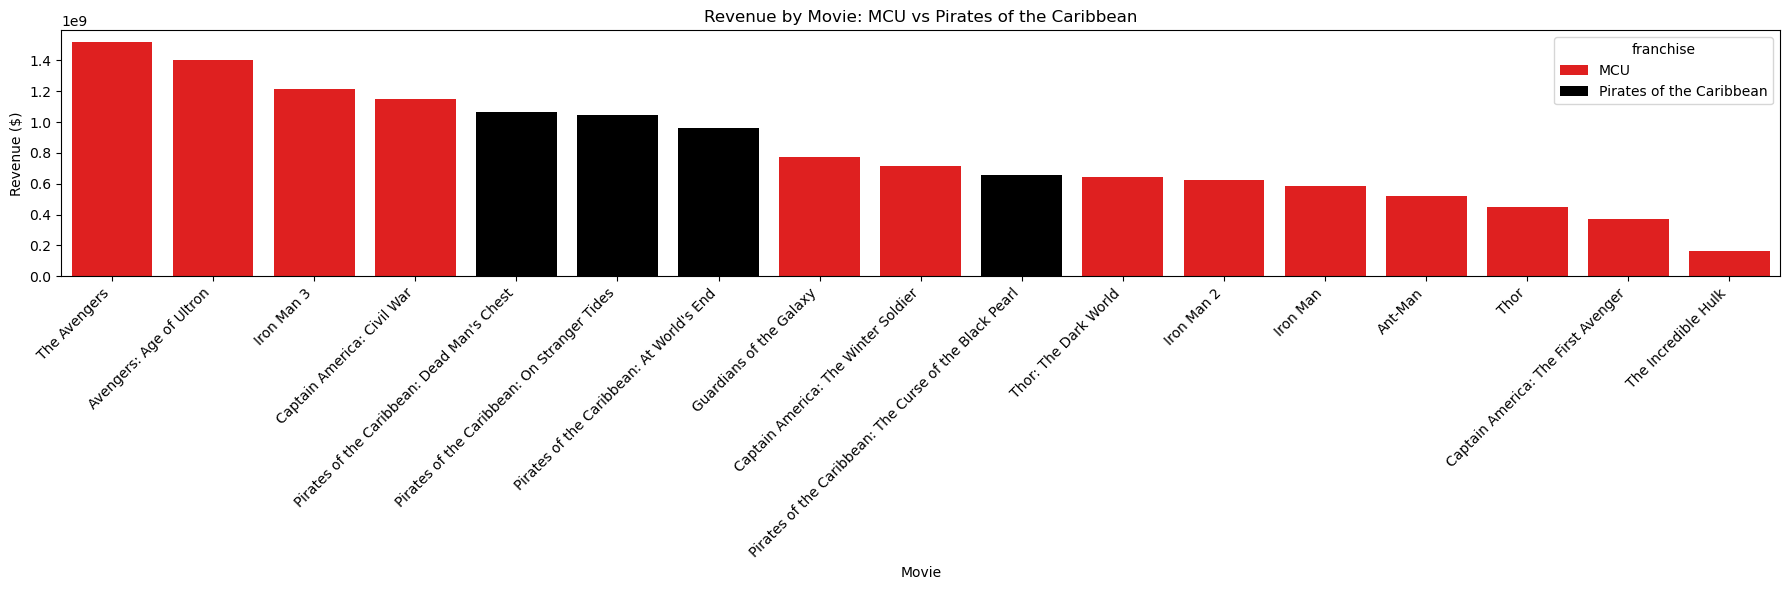

In [13]:
mcu_clean = mcu_movies[['title', 'revenue','rating_bin']].drop_duplicates(subset='title').copy()
mcu_clean['franchise'] = 'MCU'
pirates_clean = pirates_movies[['title','revenue','rating_bin']].copy()
pirates_clean['franchise'] = 'Pirates of the Caribbean'
combined = pd.concat([mcu_clean, pirates_clean])
combined = combined.sort_values('revenue', ascending=False)
plt.figure(figsize = (18,6))
sns.barplot(data=combined, x='title', y='revenue', hue='franchise', palette={'MCU': 'red', 'Pirates of the Caribbean': 'black'})
plt.title('Revenue by Movie: MCU vs Pirates of the Caribbean')
plt.xlabel('Movie')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

At the individual film level, the top two MCU entries (The Avengers and Age of Ultron) sit above every Pirates film. More tellingly, the three highest-grossing Pirates films are competitive only with mid-table MCU entries. The MCU's floor is higher than Pirates' ceiling.

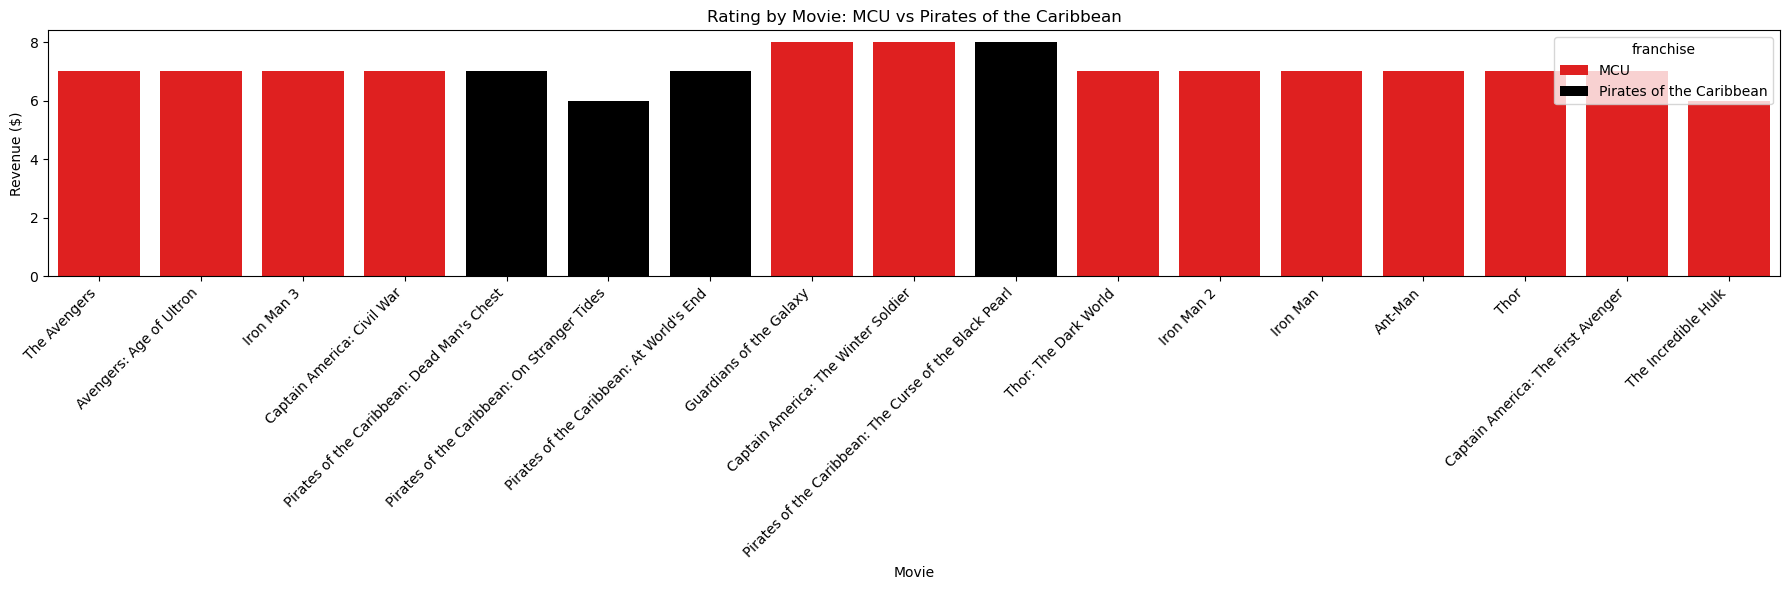

In [14]:
plt.figure(figsize = (18,6))
sns.barplot(data=combined, x='title', y='rating_bin', hue='franchise', palette={'MCU': 'red', 'Pirates of the Caribbean': 'black'})
plt.title('Rating by Movie: MCU vs Pirates of the Caribbean')
plt.xlabel('Movie')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Ratings across both franchises are virtually indistinguishable — nearly every film from both catalogues sits in the 6.5–7.5 band. The Curse of the Black Pearl scores marginally highest of all films shown. Quality is not the differentiating factor.

The revenue gap comes down entirely to franchise model. The MCU's shared universe compounds audience engagement across each new release, whereas Pirates operates as a standalone series with no such connective tissue. This is the key insight: equivalent budgets and equivalent quality produce vastly different commercial outcomes depending on franchise structure.